# Comparación de modelos para aprobación de crédito

Parcial práctico — Machine Learning, Universidad Libre.
Dataset individual: `aprobacion_credito_Arias_Becerra_Johel_Santiago_3144.csv` (1.000 solicitudes).

Trabajo en riesgo: hay que recomendar, con evidencia, un clasificador para aprobar o rechazar crédito entre un **árbol de decisión**, una **regresión logística** y una **SVM**.

Además de la tabla, el notebook muestra cómo se lee cada modelo: el dibujo del árbol, los coeficientes de la logística y la curva ROC.

Reglas de este notebook (las de clase y las del diseño):

- Un solo split: `test_size=0.25`, `random_state=11`, `stratify=y`.
- Escalamos SVM y logística con `StandardScaler` **dentro** de un `Pipeline` (el scaler se ajusta solo con train). El árbol no se escala.
- Evaluamos solo en test: accuracy, precisión, sensibilidad (recall), especificidad y AUC.
- Criterio de recomendación, declarado **antes** de ver la tabla: mirar recall, especificidad y AUC. Un modelo domina si gana al menos 2 de esas 3 por ≥ 0.03 frente a cada rival. Si el desempeño está cercano, priorizamos interpretabilidad (árbol > logística > SVM). No elegimos por accuracy: el 73.3% de las solicitudes históricas fueron rechazadas.

## Contexto


## Carga y EDA

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

COLUMNAS = [
    "ingreso_mensual_kcop",
    "score_buro",
    "antiguedad_laboral_anios",
    "num_creditos_activos",
    "dti",
    "aprobado",
]

NOMBRE_CSV = "aprobacion_credito_Arias_Becerra_Johel_Santiago_3144.csv"
RUTA_ESPERADA = f"data/{NOMBRE_CSV}"


def ruta_dataset() -> Path:
    candidatos = [
        Path("data") / NOMBRE_CSV,
        Path("../data") / NOMBRE_CSV,
        Path.cwd() / "data" / NOMBRE_CSV,
        Path.cwd().parent / "data" / NOMBRE_CSV,
    ]
    for path in candidatos:
        if path.is_file():
            return path.resolve()
    raise FileNotFoundError(
        f"No se encontró el dataset. Ruta esperada: {RUTA_ESPERADA}"
    )


def cargar_dataset(path: Path | None = None) -> pd.DataFrame:
    destino = Path(path) if path is not None else ruta_dataset()
    if not destino.is_file():
        raise FileNotFoundError(
            f"No se encontró el dataset. Ruta esperada: {RUTA_ESPERADA}"
        )
    df = pd.read_csv(destino)
    if list(df.columns) != COLUMNAS:
        raise ValueError(
            f"columnas distintas a las esperadas {COLUMNAS}; recibidas {list(df.columns)}"
        )
    if len(df) != 1000:
        raise ValueError(f"se esperaban 1000 filas; hay {len(df)}")
    if df.isna().any().any():
        raise ValueError("el dataset no debe tener nulos")
    if not set(df["aprobado"].unique()) <= {0, 1}:
        raise ValueError("aprobado debe ser 0 o 1")
    return df


def partir_train_test(df: pd.DataFrame):
    X = df.drop(columns="aprobado")
    y = df["aprobado"]
    return train_test_split(X, y, test_size=0.25, random_state=11, stratify=y)


def metricas_prueba(y_true, y_pred, y_score) -> dict[str, float]:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    if tn + fp == 0:
        raise ValueError("especificidad indefinida: no hay negativos reales")
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "especificidad": float(tn / (tn + fp)),
        "auc": float(roc_auc_score(y_true, y_score)),
    }


def construir_modelos() -> dict:
    return {
        "Árbol": DecisionTreeClassifier(max_depth=4, random_state=11),
        "Regresión logística": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(max_iter=1000, random_state=11)),
            ]
        ),
        "SVM": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("clf", SVC(kernel="rbf", probability=True, random_state=11)),
            ]
        ),
    }


In [2]:
df = cargar_dataset()
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df["aprobado"].value_counts())
print("tasa de aprobación", round(df["aprobado"].mean(), 3))

(1000, 6)
ingreso_mensual_kcop        float64
score_buro                    int64
antiguedad_laboral_anios    float64
num_creditos_activos          int64
dti                         float64
aprobado                      int64
dtype: object
ingreso_mensual_kcop        0
score_buro                  0
antiguedad_laboral_anios    0
num_creditos_activos        0
dti                         0
aprobado                    0
dtype: int64
aprobado
0    733
1    267
Name: count, dtype: int64
tasa de aprobación 0.267


In [3]:
print(df.describe().T)
print(df.groupby("aprobado")[["ingreso_mensual_kcop", "score_buro", "antiguedad_laboral_anios", "num_creditos_activos", "dti"]].mean())
print(df.corr(numeric_only=True)["aprobado"].sort_values(ascending=False))

                           count         mean          std     min       25%  \
ingreso_mensual_kcop      1000.0  3970.840000  1810.832057  245.00  2646.000   
score_buro                1000.0   647.509000    82.549199  353.00   588.750   
antiguedad_laboral_anios  1000.0    12.802000     7.415847    0.00     6.600   
num_creditos_activos      1000.0     1.354000     1.198382    0.00     0.000   
dti                       1000.0     0.352972     0.178357    0.02     0.211   
aprobado                  1000.0     0.267000     0.442614    0.00     0.000   

                               50%         75%        max  
ingreso_mensual_kcop      3778.500  4932.25000  10915.000  
score_buro                 642.500   703.00000    850.000  
antiguedad_laboral_anios    13.200    19.20000     25.200  
num_creditos_activos         1.000     2.00000      6.000  
dti                          0.334     0.47775      0.824  
aprobado                     0.000     1.00000      1.000  
          ingreso_m

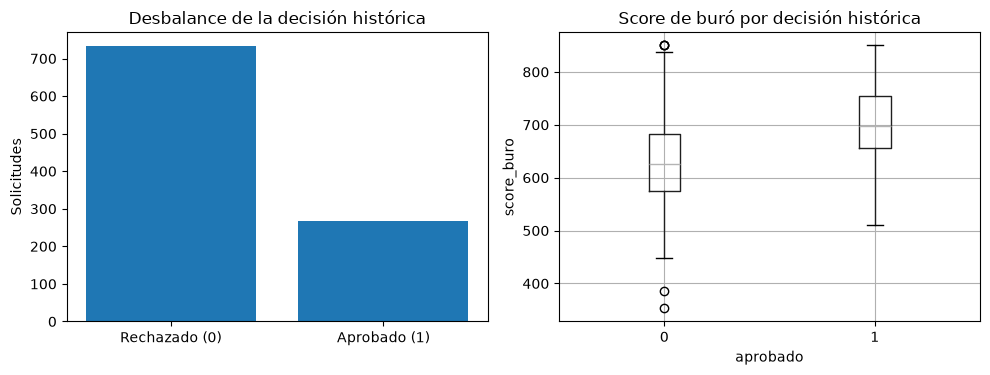

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
conteo = df["aprobado"].value_counts().sort_index()
axes[0].bar(["Rechazado (0)", "Aprobado (1)"], conteo.values)
axes[0].set_title("Desbalance de la decisión histórica")
axes[0].set_ylabel("Solicitudes")

df.boxplot(column="score_buro", by="aprobado", ax=axes[1])
axes[1].set_title("Score de buró por decisión histórica")
axes[1].set_xlabel("aprobado")
axes[1].set_ylabel("score_buro")
plt.suptitle("")
plt.tight_layout()
plt.show()

Hay **267 aprobados (26.7%)** y 733 rechazados. Sin nulos.

El score de buró es la señal más clara (media ~701 en aprobados vs ~628 en rechazados). El DTI también separa (más bajo entre aprobados). El ingreso mensual casi no cambia entre clases. Este notebook no fabrica variables nuevas: usamos las cinco columnas tal cual.

## Split

Mismo corte que en clase. `stratify=y` conserva el 26.7% de aprobados en train y test.

In [5]:
Xtr, Xte, ytr, yte = partir_train_test(df)
print(Xtr.shape, Xte.shape)
print("aprobados train", int(ytr.sum()), "tasa", round(ytr.mean(), 4))
print("aprobados test", int(yte.sum()), "tasa", round(yte.mean(), 4))

(750, 5) (250, 5)
aprobados train 200 tasa 0.2667
aprobados test 67 tasa 0.268


## Entrenamiento de los 3 modelos

- Árbol: `max_depth=4` para no memorizar train y poder explicar las reglas. No lleva scaler: los cortes no dependen de la unidad de medida.
- Logística y SVM: `Pipeline` con `StandardScaler`. La SVM es un modelo de distancia; la logística también se beneficia del escalado. `probability=True` en la SVM permite el AUC con `predict_proba` (en scikit-learn reciente puede salir un aviso de deprecación; lo dejamos porque es el contrato de este ejercicio).

In [6]:
modelos = construir_modelos()
for nombre, modelo in modelos.items():
    modelo.fit(Xtr, ytr)
    print("entrenado:", nombre)

entrenado: Árbol
entrenado: Regresión logística
entrenado: SVM


/home/ubuntu/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

arbol = modelos["Árbol"]
print("profundidad", arbol.get_depth())
print("hojas", arbol.get_n_leaves())
plt.figure(figsize=(18, 10))
plot_tree(
    arbol,
    feature_names=list(Xtr.columns),
    class_names=["Rechazado", "Aprobado"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Árbol de decisión (max_depth=4)")
plt.tight_layout()
plt.show()


El primer corte es el score de buró, en 663.50. Por encima de ese score el árbol mira el DTI; por debajo también. La celda imprime profundidad 4 y 16 hojas: `max_depth=4` es el tope elegido para poder contar estas reglas en la sustentación.


In [ ]:
from sklearn.tree import export_text

print(export_text(arbol, feature_names=list(Xtr.columns), decimals=2))


Dos caminos concretos. Si el score pasa de 663.50 y el DTI no pasa de 0.19, la hoja es aprobado. Si el score no pasa de 663.50, el DTI pasa de 0.25 y la antigüedad no pasa de 24.10 años, la hoja es rechazado. El ingreso solo aparece en ramas más profundas.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

importancias = pd.DataFrame({
    "Variable": list(Xtr.columns),
    "Importancia": modelos["Árbol"].feature_importances_,
}).sort_values("Importancia", ascending=False).reset_index(drop=True)
print(importancias.round(3))

plt.figure(figsize=(8, 4))
plt.barh(importancias["Variable"], importancias["Importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables en el árbol")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


El score de buró concentra 0.447 de la importancia y el DTI 0.385. El ingreso queda en 0.086. Estas importancias dicen qué variable parte más nodos en este árbol. No se comparan en número con los coeficientes de la logística: no están en la misma escala.


In [ ]:
import numpy as np
import pandas as pd

clf = modelos["Regresión logística"].named_steps["clf"]
coeficientes = pd.DataFrame({
    "Variable": list(Xtr.columns),
    "Coeficiente (escala estandarizada)": clf.coef_[0],
})
coeficientes["Odds Ratio"] = np.exp(coeficientes["Coeficiente (escala estandarizada)"])
coeficientes["Magnitud del efecto"] = coeficientes["Coeficiente (escala estandarizada)"].abs()
coeficientes = coeficientes.sort_values("Magnitud del efecto", ascending=False).reset_index(drop=True)
coeficientes.round(3)


Las dos variables de mayor magnitud, ya en escala estandarizada, son el score de buró (+1.127, odds ratio 3.088) y el DTI (−0.957, odds ratio 0.384). Un score más alto empuja a aprobar; un DTI más alto empuja a rechazar. Eso coincide con las medias del EDA. El ingreso casi no pesa (+0.008).


La SVM de este notebook usa kernel RBF. En ese espacio no hay un coeficiente por variable que el comité pueda leer, como sí hay en la logística. Por eso la SVM entra a la comparación por accuracy, precisión, recall, especificidad y AUC. La lectura de por qué se aprobó una solicitud queda en el árbol y en la logística.


## Métricas en test

Clase positiva = 1 (aprobado). Especificidad = TN / (TN + FP): de los que el histórico rechazó, cuántos rechazamos.

In [7]:
import pandas as pd

filas = []
predicciones = {}
for nombre, modelo in modelos.items():
    pred = modelo.predict(Xte)
    score = modelo.predict_proba(Xte)[:, 1]
    predicciones[nombre] = pred
    m = metricas_prueba(yte, pred, score)
    filas.append({"modelo": nombre, **m})

tabla = pd.DataFrame(filas).set_index("modelo")
tabla_3 = tabla.round(3)
tabla_3

,accuracy,precision,recall,especificidad,auc
modelo,,,,,
Árbol,0.700,0.426,0.343,0.831,0.683
Regresión logística,0.764,0.611,0.328,0.923,0.805
SVM,0.768,0.645,0.299,0.940,0.749


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metricas = ["accuracy", "precision", "recall", "especificidad", "auc"]
etiquetas = ["Accuracy", "Precisión", "Recall", "Especificidad", "AUC"]
nombres = list(tabla_3.index)
x = np.arange(len(metricas))
ancho = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
for i, nombre in enumerate(nombres):
    valores = [tabla_3.loc[nombre, m] for m in metricas]
    ax.bar(x + (i - 1) * ancho, valores, width=ancho, label=nombre)
ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_ylim(0, 1)
ax.set_ylabel("Valor en test")
ax.set_title("Métricas en el conjunto de prueba")
ax.legend()
plt.tight_layout()
plt.show()


El accuracy de los tres queda entre 0.700 y 0.768, alto en apariencia porque el 73.3% de las solicitudes históricas fueron rechazadas. El recall queda bajo en los tres (0.343, 0.328 y 0.299). Esta figura no elige sola al modelo.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(6, 5))
for nombre, modelo in modelos.items():
    score = modelo.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(yte, score)
    auc = tabla_3.loc[nombre, "auc"]
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC — conjunto de prueba")
plt.legend()
plt.tight_layout()
plt.show()


La curva de la logística queda por encima (AUC 0.805), luego la SVM (0.749) y después el árbol (0.683). La diagonal es un clasificador que no usa las variables. Esta figura ordena; el corte de `predict` sigue en 0.5.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(yte, pred, labels=[0, 1])
    print(nombre, "TN FP FN TP", cm.ravel().tolist(), "suma", int(cm.sum()))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Rechazo (0)", "Aprobado (1)"])
    ax.set_yticklabels(["Rechazo (0)", "Aprobado (1)"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_title(nombre)
    for fila in range(2):
        for col in range(2):
            ax.text(col, fila, str(int(cm[fila, col])), ha="center", va="center", color="black")
plt.tight_layout()
plt.show()


FP es aprobar a quien el histórico rechazó. FN es rechazar a quien el histórico aprobó. En las 250 solicitudes de prueba la logística tiene 14 FP y 45 FN; la SVM, 11 FP y 47 FN; el árbol, 31 FP y 44 FN. Cada matriz suma 250.


## Recomendación para producción

**Recomiendo la regresión logística** para este proceso de aprobación.

El criterio se declaró antes de entrenar: equilibrar recall, especificidad y AUC; si el desempeño está cercano, preferir el modelo que el equipo de riesgo pueda explicar.

En las 250 solicitudes de prueba (67 que el histórico había aprobado):

- El **árbol** acierta menos en el ranking (AUC 0.683) y deja pasar más aprobaciones dudosas (31 falsos positivos; especificidad 0.831). Sí es el más fácil de dibujar, pero aquí no está “cerca”: pierde más de 0.03 en AUC y en especificidad frente a la logística. No lo elijo solo por ser interpretable.
- La **SVM** es la más estricta (especificidad 0.940, solo 11 falsos positivos) y su accuracy es 0.768. Su recall es el más bajo (0.299) y su AUC (0.749) queda por debajo de la logística. Además, con kernel RBF no podemos decirle al comité *por qué* se aprobó una solicitud.
- La **regresión logística** tiene el mejor AUC (0.805), especificidad alta (0.923; 14 falsos positivos) y un recall (0.328) muy parecido al del árbol. Frente a la SVM, recall y especificidad están a menos de 0.03; el AUC favorece a la logística por 0.056. En ese empate práctico gana la interpretabilidad: cada variable tiene un signo (el score empuja a aprobar, el DTI a rechazar).

No uso el accuracy (0.764) como argumento principal. Un modelo que rechace todo acertaría cerca del 73% y sería inútil.

**Límite:** el recall ~0.33 significa que, de cada tres solicitudes que el histórico habría aprobado, el modelo solo recupera una. Es un filtro conservador. No ajustamos `class_weight` ni el umbral 0.5 porque el enunciado pide comparar estos tres modelos en igualdad de condiciones, no redefinir la política de cupos.

En una frase: la logística es el punto medio que el área de riesgo puede defender — ordena mejor que la SVM, se explica mejor que la SVM, y no regala el desempeño que perderíamos si nos quedáramos con el árbol.


## Uso de inteligencia artificial

- **Cursor (agente Grok):** diseño del ejercicio, especificación, plan de implementación y estructura del notebook (secciones, split, pipelines, fórmulas de especificidad).
- **Cursor (agente Grok):** dudas sobre por qué la SVM necesita `StandardScaler` y el árbol no; diferencia de `probability=True` para el AUC.
- **Cursor (agente Grok):** redacción inicial de la justificación de negocio a partir de la tabla de test; yo conservo la decisión (logística) y debo poder explicarla en la oral.
- El código de carga, split, modelos y métricas sigue el enunciado y la spec; si al implementar se depuró un error de celda con el asistente, anotarlo aquí en una viñeta extra (herramienta + celda + para qué).


## Guion de 3 a 5 minutos

1. **Problema (20 s).** 1.000 solicitudes; 26.7% aprobadas. Predigo la decisión histórica, no si el cliente va a pagar.
2. **Método (40 s).** Mismo split de clase (`random_state=11`, `stratify`). Escalo logística y SVM dentro del `Pipeline`; el árbol no, con `max_depth=4` para poder contarlo. Especificidad la calculo a mano con la matriz.
3. **Hallazgo (60 s).** En test, la logística tiene el mejor AUC (0.805). La SVM es un poco más estricta; el árbol se entiende más pero ordena peor.
4. **Decisión (90 s).** Recomiendo logística: desempeño cercano a la SVM y se explica con signos. Límite: recall bajo (~0.33), modelo conservador.
5. **IA (20 s).** Usé Cursor para el diseño y para ordenar la justificación. Las semillas, el split y las fórmulas las puedo explicar sin el chat.

Preguntas que debo poder responder: por qué 11, por qué `max_depth=4`, por qué `probability=True`, qué es un FP en crédito, por qué no me creo el accuracy.
